In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', 100)
DATA_DIR = Path('data')
RACE_YEAR = 2019
RACE_NAME = 'British Grand Prix'
N_DRIVERS = 8
RANDOM_STATE = 42


In [ ]:
# required = ['lap_times.csv', 'pit_stops.csv', 'results.csv', 'races.csv']
# missing = [f for f in required if not (DATA_DIR / f).exists()]
# if missing:
#     raise FileNotFoundError(
#         'Missing files in data/: ' + ', '.join(missing) +
#         '. Download the Kaggle dataset and copy the four CSV files into data/.'
#     )

lap_times = pd.read_csv(DATA_DIR / 'lap_times.csv')
pit_stops = pd.read_csv(DATA_DIR / 'pit_stops.csv')
results = pd.read_csv(DATA_DIR / 'results.csv')
races = pd.read_csv(DATA_DIR / 'races.csv')

print('lap_times:', lap_times.shape)
print('pit_stops :', pit_stops.shape)
print('results   :', results.shape)
print('races     :', races.shape)


lap_times: (589081, 6)
pit_stops : (11371, 7)
results   : (26759, 18)
races     : (1125, 18)


In [ ]:
races

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1120,1140,2024,20,32,Mexico City Grand Prix,2024-10-27,20:00:00,https://en.wikipedia.org/wiki/2024_Mexico_City...,2024-10-25,18:30:00,2024-10-25,22:00:00,2024-10-26,17:30:00,2024-10-26,21:00:00,\N,\N
1121,1141,2024,21,18,São Paulo Grand Prix,2024-11-03,17:00:00,https://en.wikipedia.org/wiki/2024_S%C3%A3o_Pa...,2024-11-01,14:30:00,2024-11-01,18:30:00,\N,\N,2024-11-02,18:00:00,2024-11-02,14:00:00
1122,1142,2024,22,80,Las Vegas Grand Prix,2024-11-23,06:00:00,https://en.wikipedia.org/wiki/2024_Las_Vegas_G...,2024-11-21,02:30:00,2024-11-21,06:00:00,2024-11-22,02:30:00,2024-11-22,06:00:00,\N,\N
1123,1143,2024,23,78,Qatar Grand Prix,2024-12-01,17:00:00,https://en.wikipedia.org/wiki/2024_Qatar_Grand...,2024-11-29,13:30:00,2024-11-29,17:30:00,\N,\N,2024-11-30,17:00:00,2024-11-30,13:00:00


In [ ]:
race_match = races[
    (races['year'] == RACE_YEAR) &
    (races['name'].str.lower() == RACE_NAME.lower())
]

if race_match.empty:
    raise ValueError(f'Race not found: {RACE_YEAR} {RACE_NAME}')

race = race_match.iloc[0]
RACE_ID = int(race['raceId'])
print(f"Selected race: {int(race['year'])} {race['name']} | raceId={RACE_ID}")

race_results = results[results['raceId'] == RACE_ID].copy()
completed = race_results[race_results['positionOrder'].notna()].copy()

print('Classified finishers:', len(completed))
display(completed[['driverId', 'grid', 'positionOrder', 'laps', 'statusId']].head(12))


Selected race: 2019 British Grand Prix | raceId=1019
Classified finishers: 20


,driverId,grid,positionOrder,laps,statusId
24380,1,2,1,52,1
24381,822,1,2,52,1
24382,844,3,3,52,1
24383,842,5,4,52,1
24384,830,4,5,52,1
24385,832,13,6,52,1
24386,817,7,7,52,1
24387,8,12,8,52,1
24388,826,17,9,52,1
24389,807,10,10,52,1


In [ ]:
import warnings

lap_counts = lap_times[lap_times['raceId'] == RACE_ID].groupby('driverId')['lap'].nunique()
eligible = completed[completed['driverId'].isin(lap_counts.index)].copy()
eligible['lap_count'] = eligible['driverId'].map(lap_counts)
eligible = eligible.sort_values(['lap_count', 'positionOrder'], ascending=[False, True])

selected_drivers = eligible.head(N_DRIVERS)['driverId'].tolist()
if len(selected_drivers) < 5:
    warnings.warn(f'Fewer than 5 eligible drivers ({len(selected_drivers)}) were found for this race ({RACE_ID}). Subsequent cells might fail or produce unexpected results.')


print('Selected drivers:', selected_drivers)

Selected drivers: [1, 822, 844, 842, 830, 832, 817, 8]


In [ ]:

laps = lap_times[
    (lap_times['raceId'] == RACE_ID) &
    (lap_times['driverId'].isin(selected_drivers))
].copy()

pits = pit_stops[
    (pit_stops['raceId'] == RACE_ID) &
    (pit_stops['driverId'].isin(selected_drivers))
][['driverId', 'lap']].copy()

pits['is_pit_lap'] = True
laps = laps.merge(pits, on=['driverId', 'lap'], how='left')
laps['is_pit_lap'] = laps['is_pit_lap'].fillna(False)

grid = race_results[['driverId', 'grid']].copy()
laps = laps.merge(grid, on='driverId', how='left')

laps = laps.rename(columns={'milliseconds': 'lap_time_ms'})
laps = laps.sort_values(['driverId', 'lap']).reset_index(drop=True)
print('Raw selected-driver laps:', len(laps))
display(laps.head())


Raw selected-driver laps: 416


,raceId,driverId,lap,position,time,lap_time_ms,is_pit_lap,grid
0,1019,1,1,2,1:34.895,94895,False,2
1,1019,1,2,2,1:31.923,91923,False,2
2,1019,1,3,2,1:31.635,91635,False,2
3,1019,1,4,2,1:32.058,92058,False,2
4,1019,1,5,2,1:31.540,91540,False,2


In [ ]:
before = len(laps)
laps = laps.loc[~laps['is_pit_lap']].copy()
removed_pit = before - len(laps)
driver_median = laps.groupby('driverId')['lap_time_ms'].transform('median')
outlier_mask = laps['lap_time_ms'] > 1.5 * driver_median
removed_slow = int(outlier_mask.sum())
laps = laps.loc[~outlier_mask].copy()
invalid = (laps['lap_time_ms'] <= 0) | laps['lap_time_ms'].isna() | laps['grid'].isna()
removed_invalid = int(invalid.sum())
laps = laps.loc[~invalid].copy()

removed_total = removed_pit + removed_slow + removed_invalid
print(f'Removed pit-stop laps : {removed_pit}')
print(f'Removed >1.5× median : {removed_slow}')
print(f'Removed invalid rows  : {removed_invalid}')
print(f'TOTAL REMOVED         : {removed_total}')
print(f'Remaining rows        : {len(laps)}')


Removed pit-stop laps : 12
Removed >1.5× median : 14
Removed invalid rows  : 0
TOTAL REMOVED         : 26
Remaining rows        : 390


In [ ]:
all_pit_laps = pit_stops.copy()
all_pit_laps = all_pit_laps[
    (all_pit_laps['raceId'] == RACE_ID) &
    (all_pit_laps['driverId'].isin(selected_drivers))
][['driverId', 'lap']].sort_values(['driverId', 'lap'])

def add_tire_age(group):
    driver_pits = all_pit_laps.loc[all_pit_laps['driverId'] == group.name, 'lap'].to_numpy()
    group = group.copy()
    group['last_pit_lap'] = group['lap'].apply(
        lambda x: driver_pits[driver_pits < x].max() if np.any(driver_pits < x) else 0
    )
    group['tire_age'] = group['lap'] - group['last_pit_lap']
    return group

laps = laps.groupby('driverId', group_keys=False).apply(add_tire_age)
laps['tire_age'] = laps['tire_age'].astype(int)
laps['lap_time_s'] = laps['lap_time_ms'] / 1000.0

display(laps[['driverId', 'lap', 'grid', 'tire_age', 'lap_time_s']].head(15))


,driverId,lap,grid,tire_age,lap_time_s
0,1,1,2,1,94.895
1,1,2,2,2,91.923
2,1,3,2,3,91.635
3,1,4,2,4,92.058
4,1,5,2,5,91.540
5,1,6,2,6,90.967
6,1,7,2,7,90.940
7,1,8,2,8,90.850
8,1,9,2,9,91.140
9,1,10,2,10,90.972


In [ ]:

def add_stint_number(group):
    driver_pits = all_pit_laps.loc[all_pit_laps['driverId'] == group.name, 'lap'].to_numpy()
    group = group.copy()
    group['stint'] = np.searchsorted(driver_pits, group['lap'].to_numpy(), side='left') + 1
    return group

laps = laps.groupby('driverId', group_keys=False).apply(add_stint_number)

final_stint = laps.groupby('driverId')['stint'].transform('max')
laps['split'] = np.where(laps['stint'].eq(final_stint), 'test', 'train')

train = laps[laps['split'] == 'train'].copy()
test = laps[laps['split'] == 'test'].copy()

if train.empty or test.empty:
    raise ValueError('Train/test split is empty. Choose a race with multiple stints per selected driver.')

print('Training rows:', len(train))
print('Testing rows :', len(test))
display(laps.groupby(['driverId', 'split'])['lap'].agg(['min', 'max', 'count']))


Training rows: 160
Testing rows : 230


min  max  count
driverId split                 
1        test    24   52     29
         train    1   19     19
8        test    18   52     35
         train    1   16     16
817      test    22   52     31
         train    1   19     18
822      test    46   52      7
         train    1   44     40
830      test    22   52     30
         train    1   19     18
832      test    22   52     30
         train    1   19     19
842      test    13   52     39
         train    1   11     11
844      test    24   52     29
         train    1   20     19

In [ ]:
FEATURES_BASELINE = ['grid', 'lap']
FEATURES_ENHANCED = ['grid', 'lap', 'tire_age']
TARGET = 'lap_time_ms'
X_train_base = train[FEATURES_BASELINE]
X_test_base = test[FEATURES_BASELINE]
X_train_enh = train[FEATURES_ENHANCED]
X_test_enh = test[FEATURES_ENHANCED]
y_train = train[TARGET]
y_test = test[TARGET]
models = {
    'Ridge baseline': (Ridge(alpha=10.0), FEATURES_BASELINE),
    'Random Forest baseline': (RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1), FEATURES_BASELINE),
    'Ridge + tire age': (Ridge(alpha=10.0), FEATURES_ENHANCED),
    'Random Forest + tire age': (RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1), FEATURES_ENHANCED),
}
results_table = []
predictions = {}
for name, (model, features) in models.items():
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('model', model)
    ])
    pipe.fit(train[features], y_train)
    pred = pipe.predict(test[features])
    predictions[name] = pred
    results_table.append({
        'Model': name,
        'Features': ', '.join(features),
        'RMSE (ms)': mean_squared_error(y_test, pred) ** 0.5,
        'RMSE (s)': mean_squared_error(y_test, pred) ** 0.5 / 1000,
        'MAE (ms)': mean_absolute_error(y_test, pred),
        'MAE (s)': mean_absolute_error(y_test, pred) / 1000,
    })
comparison = pd.DataFrame(results_table).sort_values('RMSE (ms)')
display(comparison.round(3))


,Model,Features,RMSE (ms),RMSE (s),MAE (ms),MAE (s)
3,Random Forest + tire age,"grid, lap, tire_age",6742.364,6.742,2443.954,2.444
2,Ridge + tire age,"grid, lap, tire_age",7057.125,7.057,3497.684,3.498
1,Random Forest baseline,"grid, lap",7258.200,7.258,2380.682,2.381
0,Ridge baseline,"grid, lap",7380.192,7.380,2391.056,2.391


In [ ]:
rf_base_rmse = comparison.loc[comparison['Model'].eq('Random Forest baseline'), 'RMSE (ms)'].iloc[0]
rf_enh_rmse = comparison.loc[comparison['Model'].eq('Random Forest + tire age'), 'RMSE (ms)'].iloc[0]
improvement = 100 * (rf_base_rmse - rf_enh_rmse) / rf_base_rmse
print(f'Random Forest RMSE improvement from tire_age: {improvement:.2f}%')


Random Forest RMSE improvement from tire_age: 7.11%


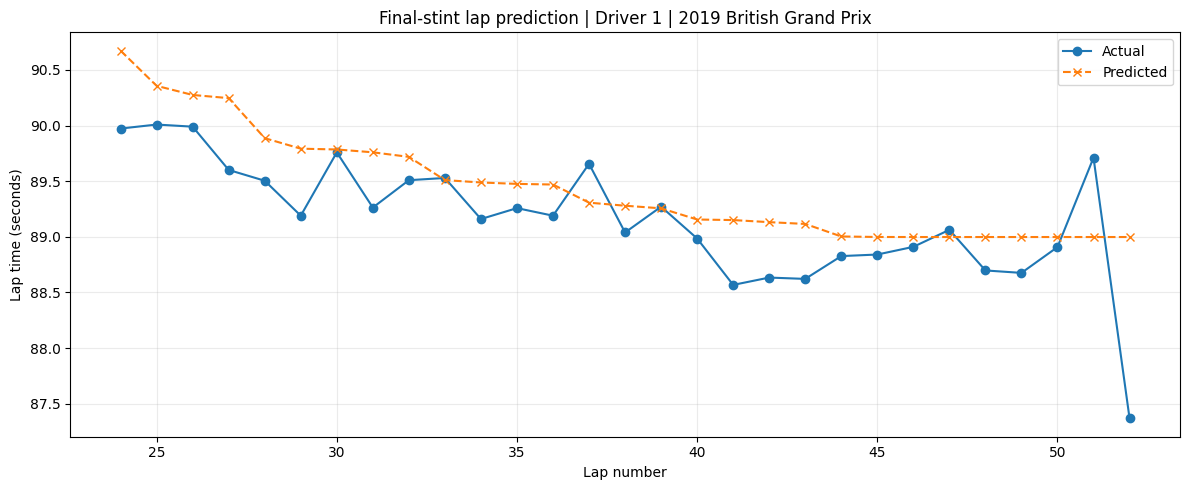

In [ ]:
best_model_name = comparison.iloc[0]['Model']
test_plot = test.copy()
test_plot['predicted_ms'] = predictions[best_model_name]
plot_driver = selected_drivers[0]
plot_data = test_plot[test_plot['driverId'] == plot_driver].sort_values('lap')
plt.figure(figsize=(12, 5))
plt.plot(plot_data['lap'], plot_data['lap_time_s'], marker='o', label='Actual')
plt.plot(plot_data['lap'], plot_data['predicted_ms'] / 1000, marker='x', linestyle='--', label='Predicted')
plt.xlabel('Lap number')
plt.ylabel('Lap time (seconds)')
plt.title(f'Final-stint lap prediction | Driver {plot_driver} | {RACE_YEAR} {RACE_NAME}')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


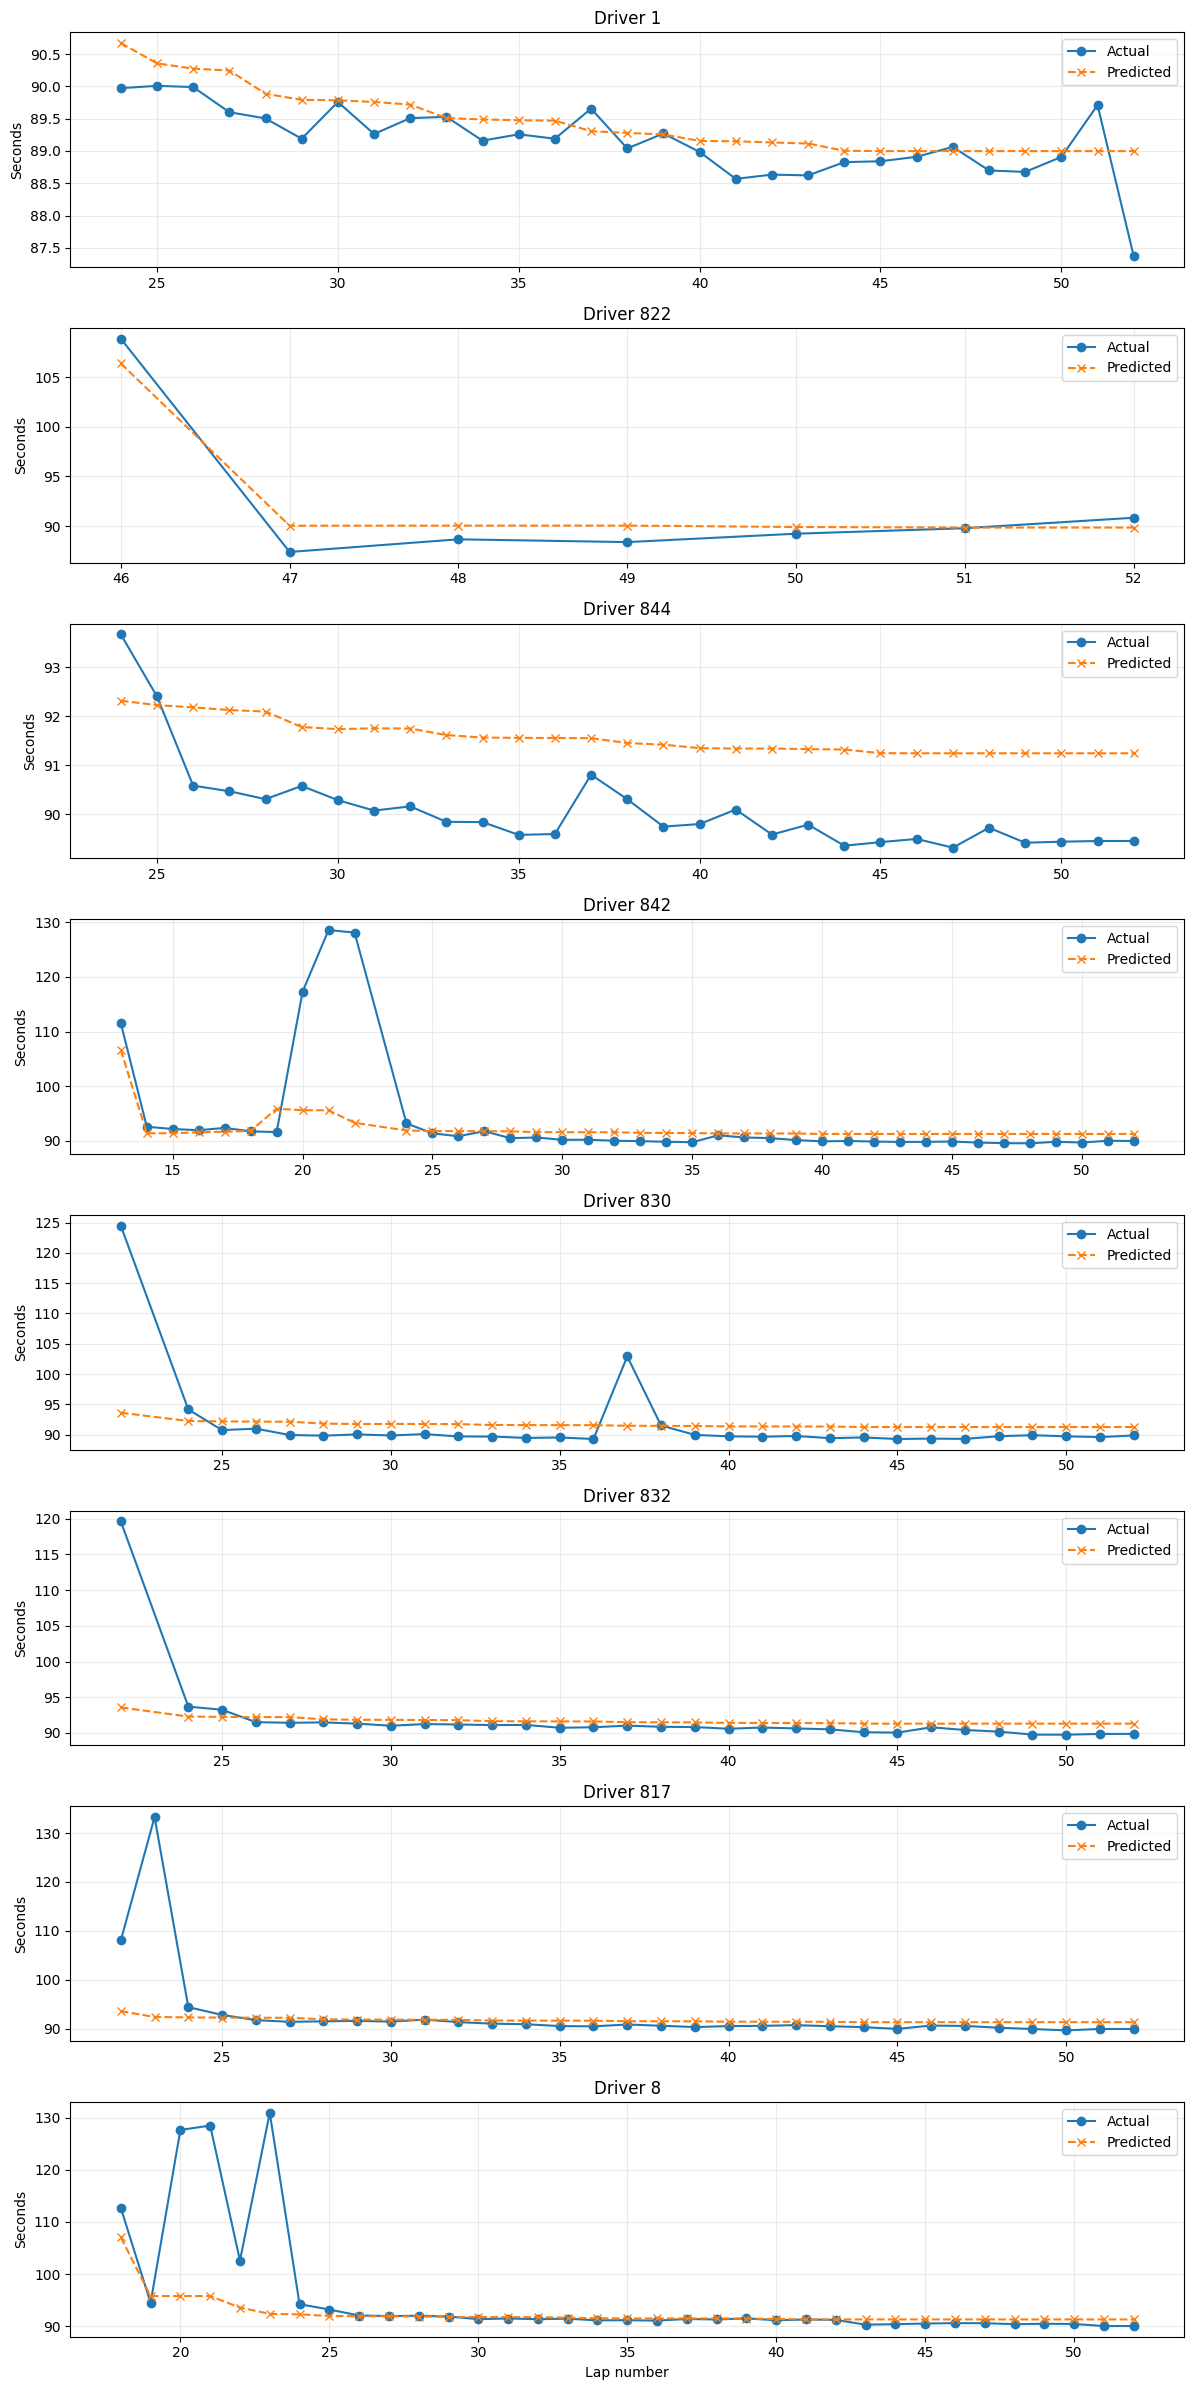

In [ ]:
fig, axes = plt.subplots(len(selected_drivers), 1, figsize=(12, 3 * len(selected_drivers)), sharex=False)
if len(selected_drivers) == 1:
    axes = [axes]

for ax, driver_id in zip(axes, selected_drivers):
    d = test_plot[test_plot['driverId'] == driver_id].sort_values('lap')
    ax.plot(d['lap'], d['lap_time_s'], marker='o', label='Actual')
    ax.plot(d['lap'], d['predicted_ms'] / 1000, marker='x', linestyle='--', label='Predicted')
    ax.set_ylabel('Seconds')
    ax.set_title(f'Driver {driver_id}')
    ax.legend()
    ax.grid(alpha=0.25)

axes[-1].set_xlabel('Lap number')
plt.tight_layout()
plt.show()
